# House Price Prediction — Complete Final Project

This notebook combines the complete House Prices project into one reproducible workflow: initial inspection, baseline, exploratory analysis, hypothesis testing, missing-value and outlier analysis, data cleaning, Feature Engineering, model comparison, cross-validation, hyperparameter tuning, ensemble testing, final holdout evaluation, error analysis, and a saved production-ready model.

**Problem:** predict a house sale price from its characteristics. This is a supervised regression task.

**Main selection metric:** RMSLE. MAE, RMSE, and R² are reported as complementary metrics.

## 1. Imports and configuration

All random operations use `random_state=0`. A final 30% holdout is separated before exploratory decisions and is evaluated only after model selection.

In [1]:
from pathlib import Path
import warnings

import cloudpickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor, RandomForestRegressor,
    StackingRegressor, VotingRegressor
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    confusion_matrix, mean_absolute_error, mean_squared_error,
    mean_squared_log_error, r2_score
)
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 0
HOLDOUT_SIZE = 0.30

## 2. Load and inspect the data

In [2]:
# Find the dataset whether the notebook is run from the project root or its own folder.
data_candidates = [
    Path('houseprice.csv')
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('houseprice.csv was not found in the expected project locations.')

data = pd.read_csv(data_path)
print('Dataset path:', data_path.resolve())
print('Rows:', data.shape[0])
print('Columns:', data.shape[1])
display(data.head())

Dataset path: C:\KS_AI_JLKZ_25\houseprice.csv
Rows: 1460
Columns: 81


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Review feature types, missing values, duplicates, and the target.
numeric_columns = data.select_dtypes(include='number').columns.tolist()
categorical_columns = data.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numerical columns:', len(numeric_columns))
print('Categorical columns:', len(categorical_columns))
print('Duplicate rows:', data.duplicated().sum())
print('Duplicate Id values:', data['Id'].duplicated().sum())
print('Missing target values:', data['SalePrice'].isna().sum())

column_summary = pd.DataFrame({
    'dtype': data.dtypes.astype(str),
    'unique': data.nunique(dropna=True),
    'missing': data.isna().sum(),
    'missing_pct': data.isna().mean().mul(100)
}).sort_values('missing_pct', ascending=False)
display(column_summary.round(2))

Numerical columns: 38
Categorical columns: 43
Duplicate rows: 0
Duplicate Id values: 0
Missing target values: 0


,dtype,unique,missing,missing_pct
PoolQC,object,3,1453,99.52
MiscFeature,object,4,1406,96.30
Alley,object,2,1369,93.77
Fence,object,4,1179,80.75
MasVnrType,object,3,872,59.73
...,...,...,...,...
MoSold,int64,12,0,0.00
YrSold,int64,5,0,0.00
SaleType,object,9,0,0.00
SaleCondition,object,6,0,0.00


In [4]:
# Separate the untouched holdout before EDA, Feature Engineering, and model selection.
X = data.drop(columns=['SalePrice', 'Id'])
y = data['SalePrice'].astype(float)
y_log = np.log1p(y)

X_dev_raw, X_holdout_raw, y_dev_log, y_holdout_log = train_test_split(
    X, y_log,
    test_size=HOLDOUT_SIZE,
    random_state=RANDOM_STATE
)

y_dev = np.expm1(y_dev_log)
y_holdout = np.expm1(y_holdout_log)
dev_data = X_dev_raw.copy()
dev_data['SalePrice'] = y_dev
holdout_ids = data.loc[X_holdout_raw.index, 'Id']

print('Development set:', X_dev_raw.shape)
print('Final holdout:', X_holdout_raw.shape)
print('Development median price:', round(y_dev.median(), 2))
print('Holdout median price:', round(y_holdout.median(), 2))

Development set: (1022, 79)
Final holdout: (438, 79)
Development median price: 163000.0
Holdout median price: 163700.0


## 3. Target distribution and simple baseline

`SalePrice` has a long right tail. The project models `log1p(SalePrice)`, which reduces skewness and makes relative errors more important than absolute differences between very expensive houses.

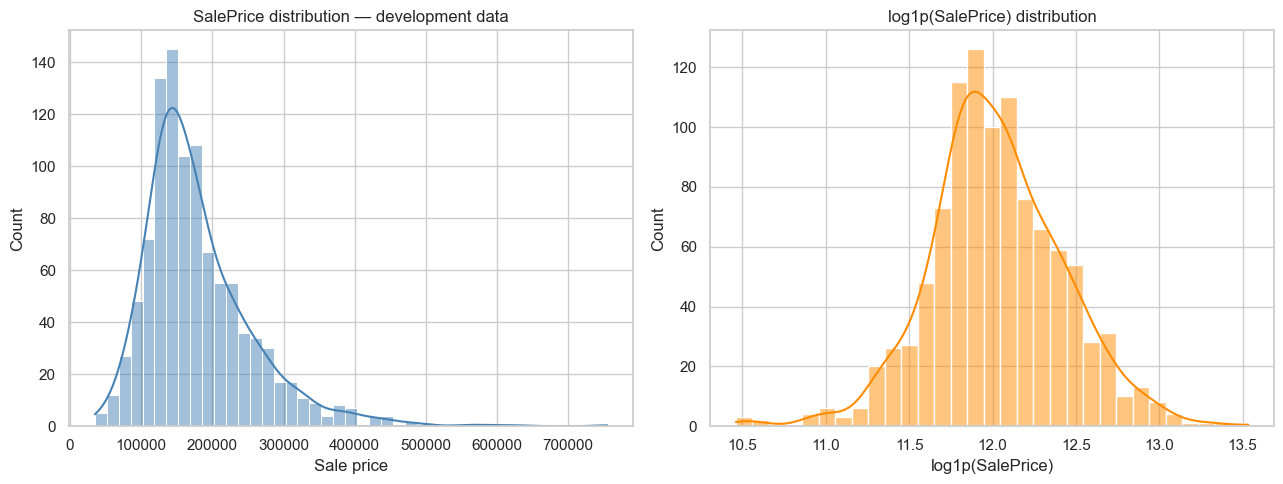

Original target skewness: 1.751
Log-transformed target skewness: -0.005


,SalePrice
count,1022.00
mean,180586.23
std,78139.17
min,34900.00
25%,130312.50
50%,163000.00
75%,214800.00
max,755000.00


In [5]:
# Compare the original and logarithmic target distributions using development data only.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(y_dev, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice distribution — development data')
axes[0].set_xlabel('Sale price')
sns.histplot(y_dev_log, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('log1p(SalePrice) distribution')
axes[1].set_xlabel('log1p(SalePrice)')
plt.tight_layout()
plt.show()

print('Original target skewness:', round(y_dev.skew(), 3))
print('Log-transformed target skewness:', round(y_dev_log.skew(), 3))
display(y_dev.describe().to_frame('SalePrice').round(2))

In [6]:
# Establish a constant median-price baseline using only a temporary development split.
X_base_train, X_base_valid, y_base_train_log, y_base_valid_log = train_test_split(
    X_dev_raw, y_dev_log,
    test_size=0.25,
    random_state=RANDOM_STATE
)
dummy = DummyRegressor(strategy='median')
dummy.fit(X_base_train, y_base_train_log)
dummy_valid_log = dummy.predict(X_base_valid)
dummy_valid_price = np.expm1(dummy_valid_log)
y_base_valid = np.expm1(y_base_valid_log)

baseline_metrics = pd.DataFrame([{
    'RMSLE': np.sqrt(mean_squared_error(y_base_valid_log, dummy_valid_log)),
    'MAE': mean_absolute_error(y_base_valid, dummy_valid_price),
    'RMSE': np.sqrt(mean_squared_error(y_base_valid, dummy_valid_price)),
    'R2': r2_score(y_base_valid, dummy_valid_price)
}])
display(baseline_metrics.round(4))

,RMSLE,MAE,RMSE,R2
0,0.4242,58000.3939,83255.7571,-0.0367


## 4. Exploratory analysis and hypotheses

The hypotheses are checked only on the development set. Relationships and correlations indicate association, not causation.

,correlation_with_sale_price
OverallQual,0.784
GrLivArea,0.725
GarageCars,0.653
GarageArea,0.645
TotalBsmtSF,0.625
1stFlrSF,0.610
FullBath,0.573
TotRmsAbvGrd,0.545
YearBuilt,0.513
YearRemodAdd,0.512


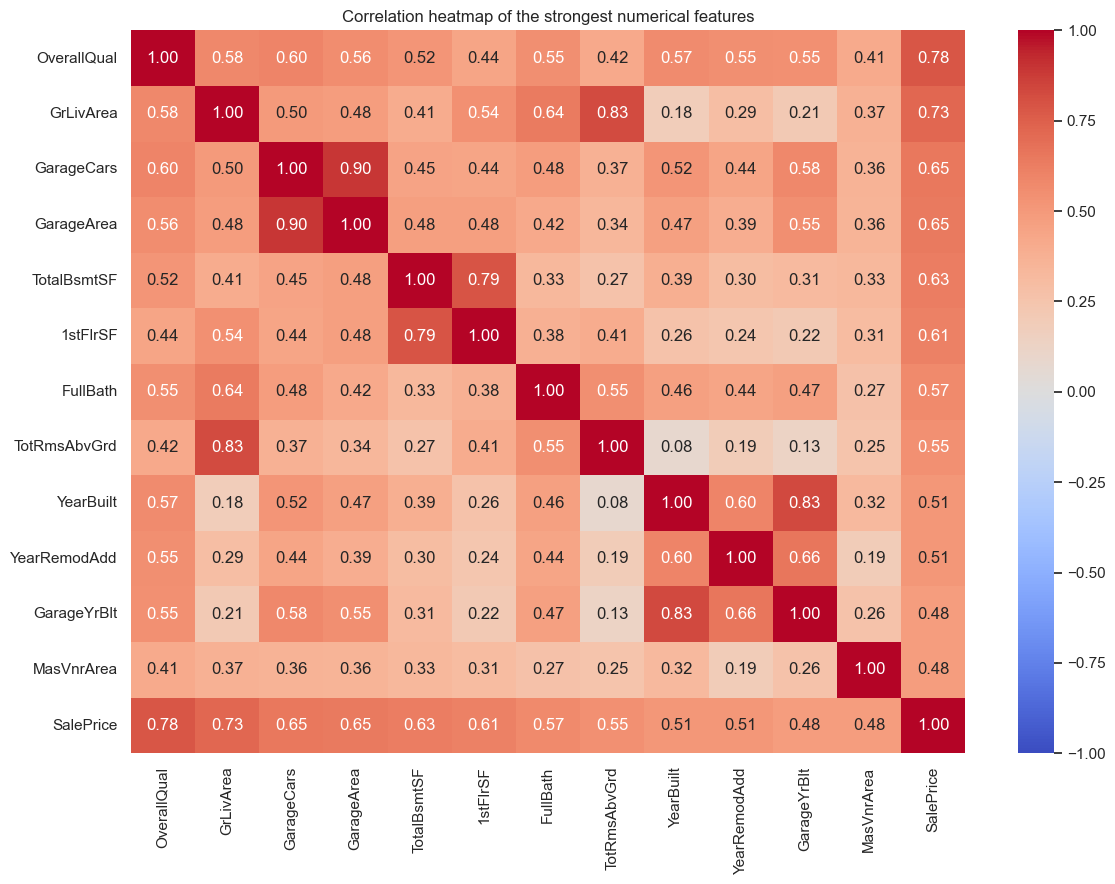

In [7]:
# Review numerical correlations with the target.
dev_numeric = dev_data.select_dtypes(include='number')
target_correlations = (
    dev_numeric.corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(key=abs, ascending=False)
)
display(target_correlations.to_frame('correlation_with_sale_price').round(3))

heatmap_features = target_correlations.head(12).index.tolist() + ['SalePrice']
plt.figure(figsize=(12, 9))
sns.heatmap(
    dev_data[heatmap_features].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1
)
plt.title('Correlation heatmap of the strongest numerical features')
plt.tight_layout()
plt.show()

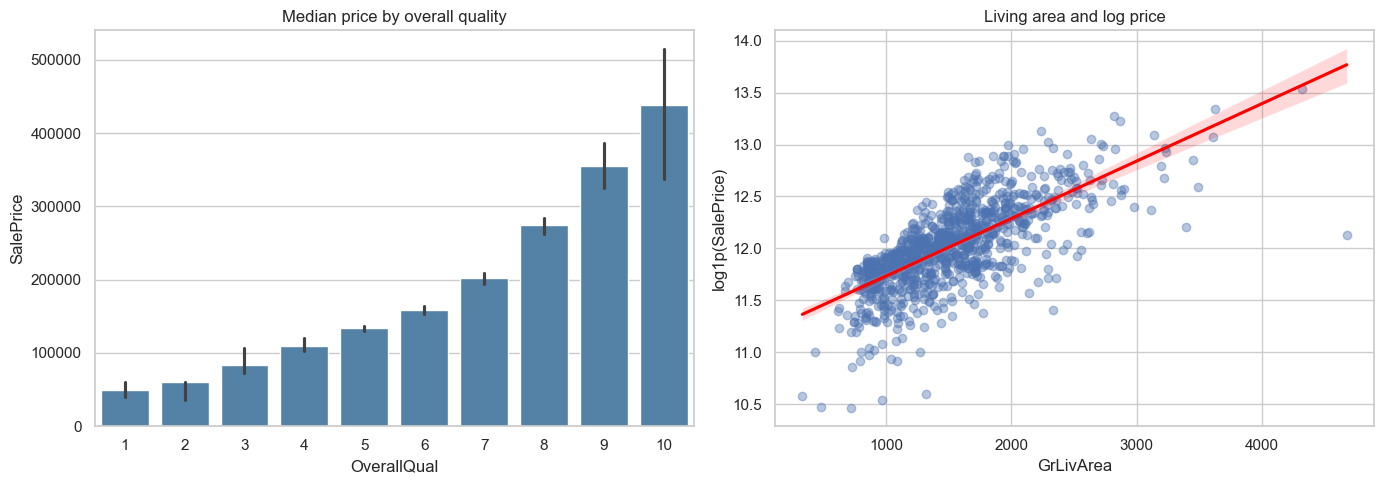

OverallQual correlation: 0.784
GrLivArea correlation: 0.725


In [8]:
# H1 and H2: overall quality and living area should be strongly related to price.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=dev_data, x='OverallQual', y='SalePrice', estimator=np.median, color='steelblue', ax=axes[0])
axes[0].set_title('Median price by overall quality')
sns.regplot(
    data=dev_data, x='GrLivArea', y=np.log1p(dev_data['SalePrice']),
    scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=axes[1]
)
axes[1].set_title('Living area and log price')
axes[1].set_ylabel('log1p(SalePrice)')
plt.tight_layout()
plt.show()

print('OverallQual correlation:', round(dev_data['OverallQual'].corr(dev_data['SalePrice']), 3))
print('GrLivArea correlation:', round(dev_data['GrLivArea'].corr(dev_data['SalePrice']), 3))

,houses,median_price
Neighborhood,,
NridgHt,51,309000.0
NoRidge,30,301750.0
StoneBr,16,280500.0
Veenker,6,231750.0
Timber,30,224000.0
Somerst,56,220500.0
CollgCr,105,203000.0
Crawfor,35,200100.0
ClearCr,24,195000.0


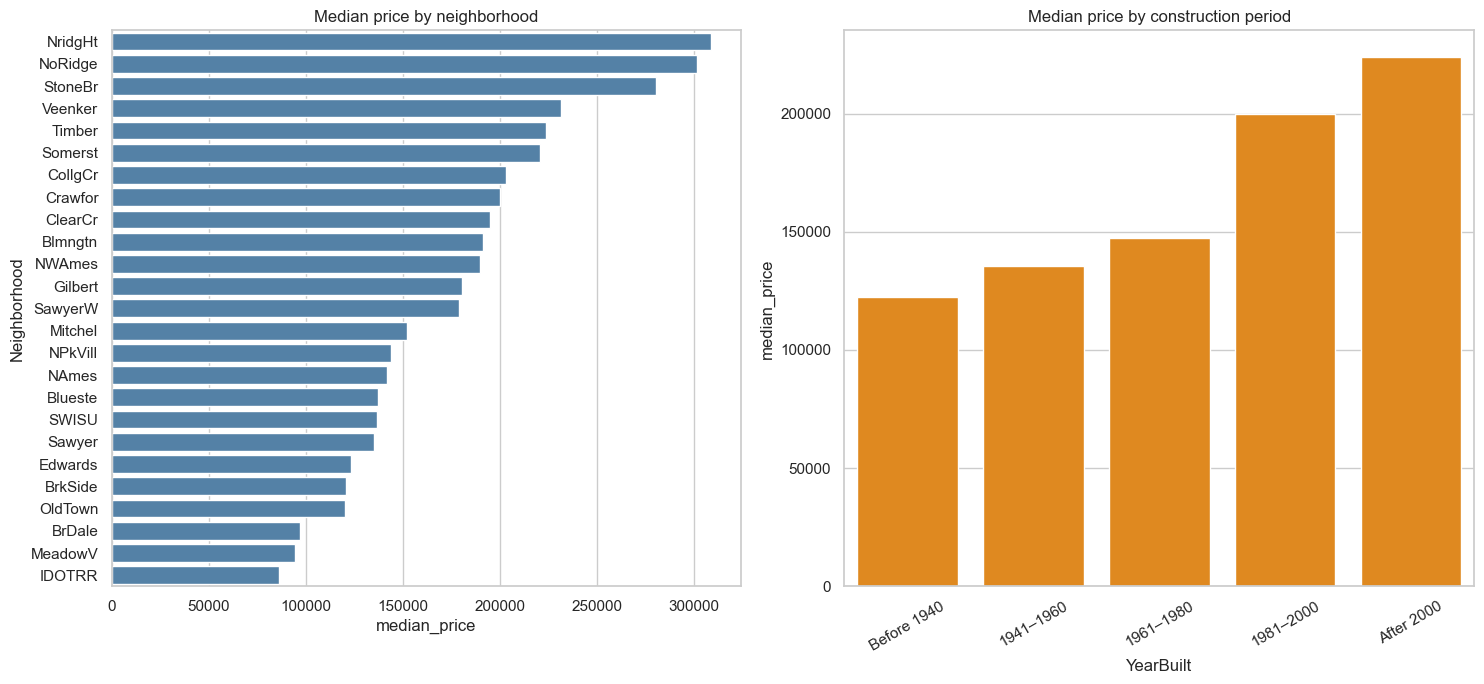

In [9]:
# H3 and H4: neighborhood and construction period should separate price levels.
neighborhood_summary = (
    dev_data.groupby('Neighborhood')['SalePrice']
    .agg(houses='size', median_price='median')
    .sort_values('median_price', ascending=False)
)
display(neighborhood_summary.round(0))

year_period = pd.cut(
    dev_data['YearBuilt'],
    bins=[1870, 1940, 1960, 1980, 2000, 2010],
    labels=['Before 1940', '1941–1960', '1961–1980', '1981–2000', 'After 2000']
)
year_summary = dev_data.groupby(year_period, observed=False)['SalePrice'].agg(
    houses='size', median_price='median'
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
sns.barplot(
    data=neighborhood_summary.reset_index(), y='Neighborhood', x='median_price',
    color='steelblue', ax=axes[0]
)
axes[0].set_title('Median price by neighborhood')
sns.barplot(data=year_summary.reset_index(), x='YearBuilt', y='median_price', color='darkorange', ax=axes[1])
axes[1].set_title('Median price by construction period')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

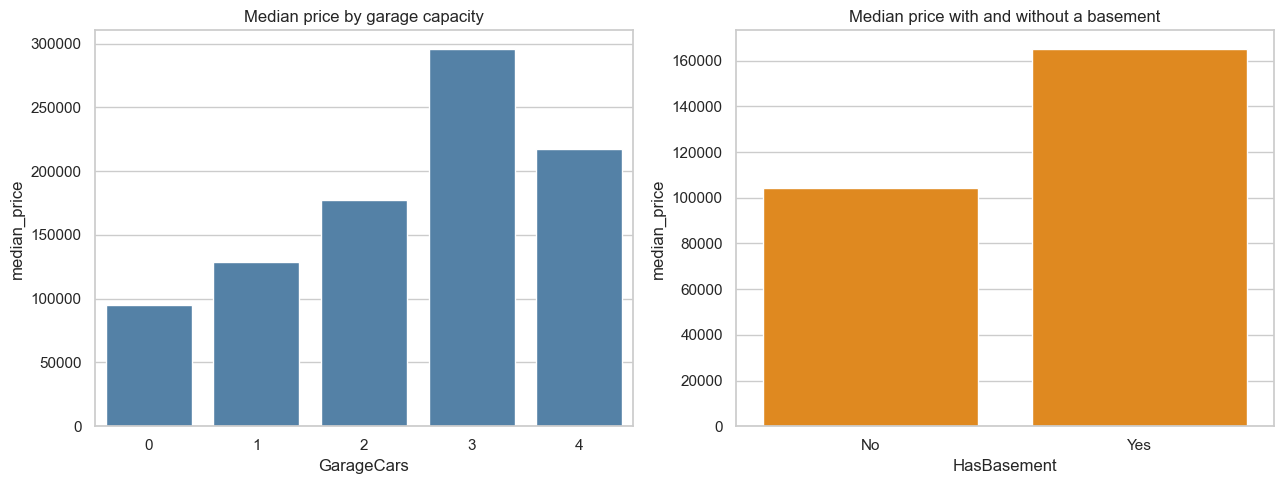

GarageCars correlation: 0.653
TotalBsmtSF correlation: 0.625


In [10]:
# H5 and H6: garage capacity and basement area should be associated with price.
garage_summary = dev_data.groupby('GarageCars')['SalePrice'].agg(
    houses='size', median_price='median'
).reset_index()
dev_data_eda = dev_data.copy()
dev_data_eda['HasBasement'] = np.where(dev_data_eda['TotalBsmtSF'] > 0, 'Yes', 'No')
basement_summary = dev_data_eda.groupby('HasBasement')['SalePrice'].agg(
    houses='size', median_price='median'
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=garage_summary, x='GarageCars', y='median_price', color='steelblue', ax=axes[0])
axes[0].set_title('Median price by garage capacity')
sns.barplot(data=basement_summary, x='HasBasement', y='median_price', color='darkorange', ax=axes[1])
axes[1].set_title('Median price with and without a basement')
plt.tight_layout()
plt.show()

print('GarageCars correlation:', round(dev_data['GarageCars'].corr(dev_data['SalePrice']), 3))
print('TotalBsmtSF correlation:', round(dev_data['TotalBsmtSF'].corr(dev_data['SalePrice']), 3))

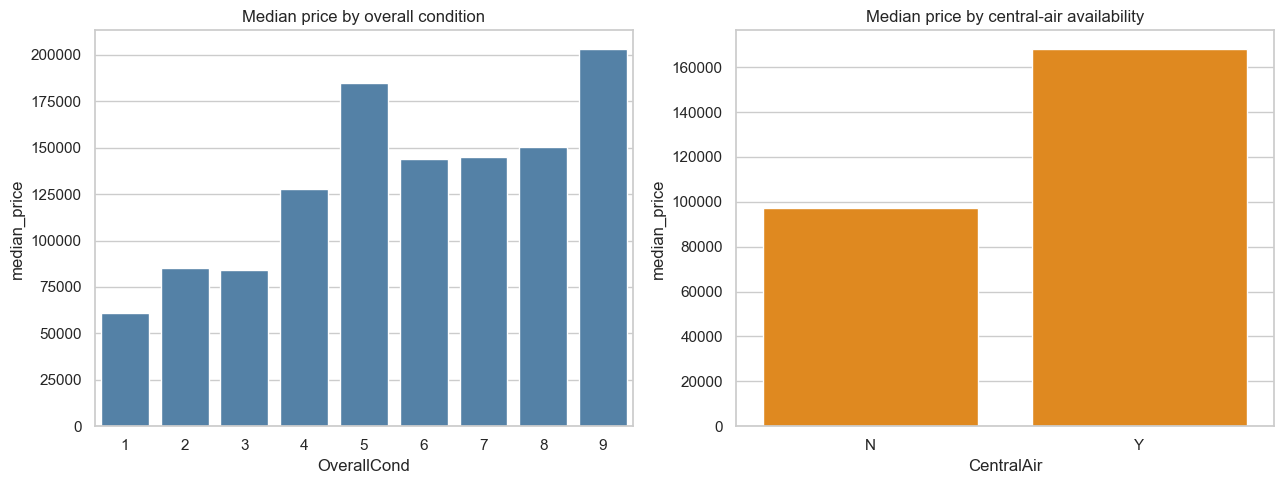

OverallCond correlation: -0.037


,CentralAir,houses,median_price
0,N,70,97250.0
1,Y,952,168000.0


In [11]:
# H7 and H8: overall condition may be weaker than expected, while central air should separate prices.
condition_summary = dev_data.groupby('OverallCond')['SalePrice'].agg(
    houses='size', median_price='median'
).reset_index()
air_summary = dev_data.groupby('CentralAir')['SalePrice'].agg(
    houses='size', median_price='median'
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=condition_summary, x='OverallCond', y='median_price', color='steelblue', ax=axes[0])
axes[0].set_title('Median price by overall condition')
sns.barplot(data=air_summary, x='CentralAir', y='median_price', color='darkorange', ax=axes[1])
axes[1].set_title('Median price by central-air availability')
plt.tight_layout()
plt.show()

print('OverallCond correlation:', round(dev_data['OverallCond'].corr(dev_data['SalePrice']), 3))
display(air_summary.round(0))

### Hypothesis conclusion

Overall quality, living area, neighborhood, construction year, garage capacity, basement area, and central-air availability carry useful price information. Overall condition is much weaker than expected because it differs from construction and finish quality. These findings motivate both the preprocessing and the engineered aggregate features.

## 5. Missing values, categories, and outliers

,missing,missing_pct,dtype
PoolQC,1019,99.71,object
MiscFeature,978,95.69,object
Alley,960,93.93,object
Fence,831,81.31,object
MasVnrType,614,60.08,object
FireplaceQu,478,46.77,object
LotFrontage,189,18.49,float64
GarageType,54,5.28,object
GarageYrBlt,54,5.28,float64
GarageFinish,54,5.28,object


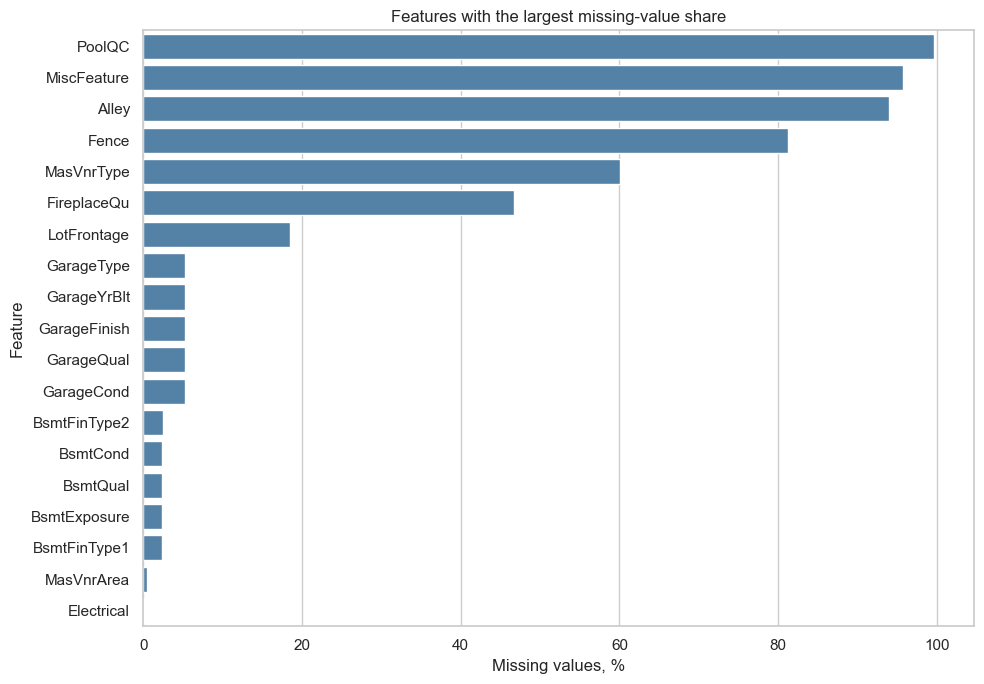

In [12]:
# Analyze missing values using development data only.
missing_summary = pd.DataFrame({
    'missing': X_dev_raw.isna().sum(),
    'missing_pct': X_dev_raw.isna().mean().mul(100),
    'dtype': X_dev_raw.dtypes.astype(str)
}).query('missing > 0').sort_values('missing_pct', ascending=False)
display(missing_summary.round(2))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=missing_summary.head(20).reset_index(),
    x='missing_pct', y='index', color='steelblue'
)
plt.title('Features with the largest missing-value share')
plt.xlabel('Missing values, %')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [13]:
# Check whether missing PoolQC and MiscFeature mainly indicate an absent amenity.
missing_meaning_rows = []
for column in ['PoolQC', 'MiscFeature']:
    groups = dev_data.assign(status=np.where(dev_data[column].isna(), 'Missing', 'Present'))
    summary = groups.groupby('status')['SalePrice'].agg(houses='size', median_price='median')
    for status, row in summary.iterrows():
        missing_meaning_rows.append({
            'feature': column,
            'status': status,
            'houses': row['houses'],
            'median_price': row['median_price']
        })
display(pd.DataFrame(missing_meaning_rows).round(0))

print('Houses with PoolArea > 0:', int((X_dev_raw['PoolArea'] > 0).sum()))
print('Non-missing PoolQC:', int(X_dev_raw['PoolQC'].notna().sum()))
print('Non-zero MiscVal:', int((X_dev_raw['MiscVal'] > 0).sum()))
print('Non-missing MiscFeature:', int(X_dev_raw['MiscFeature'].notna().sum()))

,feature,status,houses,median_price
0,PoolQC,Missing,1019.0,162900.0
1,PoolQC,Present,3.0,235000.0
2,MiscFeature,Missing,978.0,164600.0
3,MiscFeature,Present,44.0,144000.0


Houses with PoolArea > 0: 3
Non-missing PoolQC: 3
Non-zero MiscVal: 43
Non-missing MiscFeature: 44


In [14]:
# Inspect rare categorical levels.
category_rows = []
for column in X_dev_raw.select_dtypes(include=['object', 'category']).columns:
    counts = X_dev_raw[column].value_counts(dropna=False)
    category_rows.append({
        'feature': column,
        'categories_including_missing': len(counts),
        'smallest_group': counts.min(),
        'largest_group_pct': counts.max() / len(X_dev_raw) * 100
    })
category_summary = pd.DataFrame(category_rows).sort_values(
    ['largest_group_pct', 'smallest_group'], ascending=[False, True]
)
display(category_summary.round(2))

,feature,categories_including_missing,smallest_group,largest_group_pct
5,Utilities,2,1,99.90
38,PoolQC,3,1,99.71
1,Street,2,5,99.51
10,Condition2,5,1,99.32
14,RoofMatl,6,1,97.95
26,Heating,6,1,97.85
40,MiscFeature,4,2,95.69
7,LandSlope,3,10,94.13
2,Alley,3,30,93.93
28,CentralAir,2,70,93.15


,feature,lower_bound,upper_bound,outside_iqr
0,GrLivArea,165.6,2764.6,22
1,LotArea,1962.2,17376.2,66
2,TotalBsmtSF,94.9,1985.9,42
3,GarageArea,-53.4,953.6,12
4,1stFlrSF,123.5,2151.5,11
5,YearBuilt,1885.0,2069.0,6


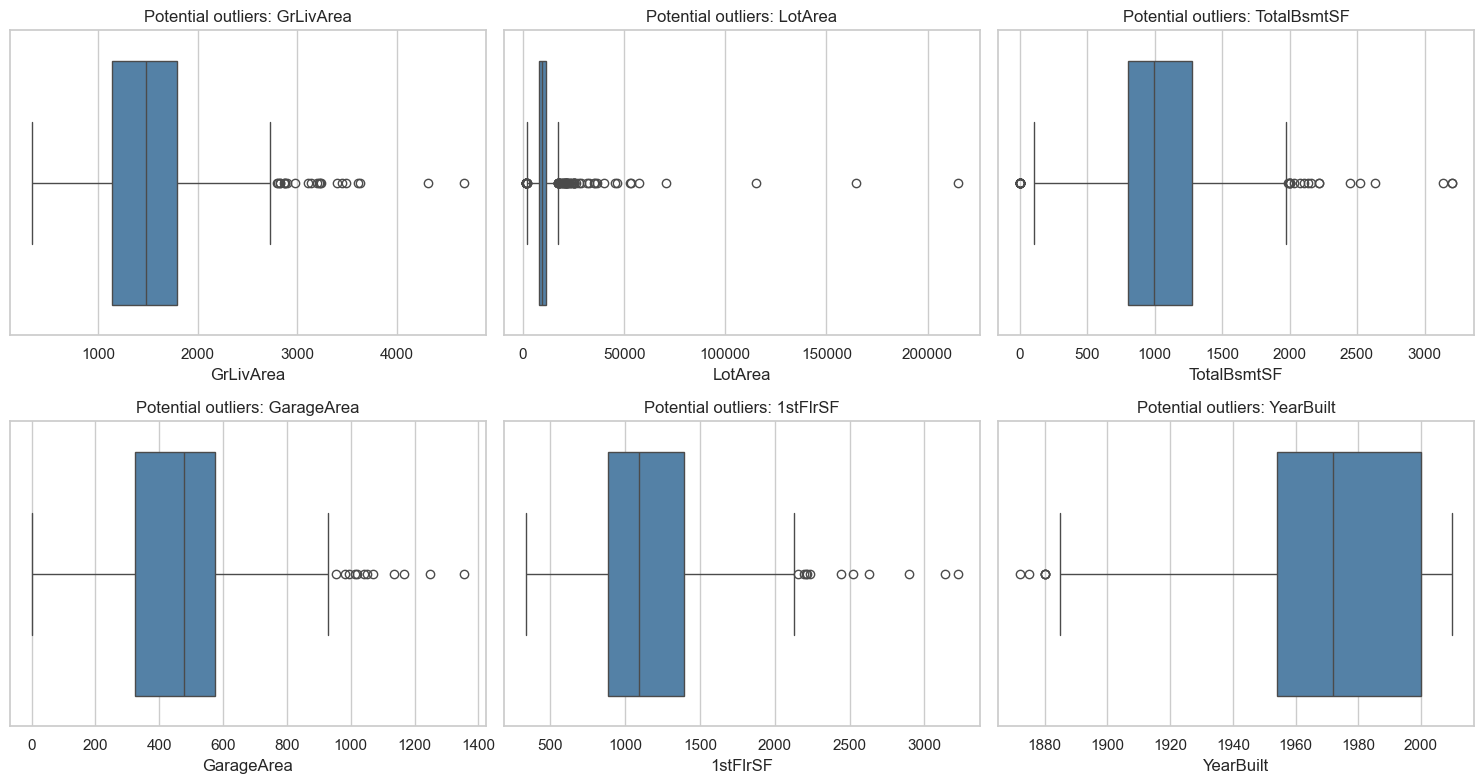

In [15]:
# Count potential outliers using the IQR rule and visualize the main continuous features.
def iqr_outlier_summary(series):
    series = series.dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return lower, upper, count

outlier_features = ['GrLivArea', 'LotArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF', 'YearBuilt']
outlier_rows = []
for column in outlier_features:
    lower, upper, count = iqr_outlier_summary(X_dev_raw[column])
    outlier_rows.append({
        'feature': column, 'lower_bound': lower,
        'upper_bound': upper, 'outside_iqr': count
    })
display(pd.DataFrame(outlier_rows).round(1))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, column in zip(axes.flat, outlier_features):
    sns.boxplot(x=X_dev_raw[column], ax=axis, color='steelblue')
    axis.set_title(f'Potential outliers: {column}')
plt.tight_layout()
plt.show()

In [16]:
# Review unusually large houses before deciding whether to remove anything.
large_house_check = dev_data.loc[
    dev_data['GrLivArea'] > 4000,
    ['GrLivArea', 'OverallQual', 'YearBuilt', 'Neighborhood', 'SalePrice']
].sort_values('GrLivArea', ascending=False)
display(large_house_check)

,GrLivArea,OverallQual,YearBuilt,Neighborhood,SalePrice
523,4676,10,2007,Edwards,184750.0
691,4316,10,1994,NoRidge,755000.0


### Cleaning decisions

- Missing categories that mean an absent object are filled with `None`.
- Missing numerical quantities for an absent object are filled with `0`.
- Ordinary numerical gaps, such as `LotFrontage`, are imputed with the training median.
- Ordinary categorical gaps, such as `Electrical`, are imputed with the most frequent training category.
- Rare categories are retained and handled by one-hot encoding with unknown-category support.
- Potential outliers are not deleted automatically. They can be real luxury, large-lot, or unusual houses, and the log target reduces their dominance.
- Every learned preprocessing statistic is fitted inside the pipeline and inside each cross-validation fold.

## 6. Semantic cleaning and Feature Engineering

In [17]:
# Encode structural absence according to the meaning of the data dictionary.
absence_categorical = [
    'Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC',
    'Fence', 'MiscFeature'
]
absence_numeric = [
    'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
    'GarageYrBlt', 'GarageCars', 'GarageArea'
]


def fill_absence_values(df):
    result = df.copy()
    for column in absence_categorical:
        if column in result.columns:
            result[column] = result[column].fillna('None')
    for column in absence_numeric:
        if column in result.columns:
            result[column] = result[column].fillna(0)
    return result

In [18]:
# Create all 15 candidate engineered features from the earlier experiment.
def create_all_candidate_features(df):
    result = df.copy()
    result['TotalSF'] = result['TotalBsmtSF'] + result['1stFlrSF'] + result['2ndFlrSF']
    result['TotalBathrooms'] = (
        result['FullBath'] + 0.5 * result['HalfBath']
        + result['BsmtFullBath'] + 0.5 * result['BsmtHalfBath']
    )
    result['TotalPorchSF'] = (
        result['OpenPorchSF'] + result['EnclosedPorch']
        + result['3SsnPorch'] + result['ScreenPorch'] + result['WoodDeckSF']
    )
    result['HouseAge'] = (result['YrSold'] - result['YearBuilt']).clip(lower=0)
    result['RemodelAge'] = (result['YrSold'] - result['YearRemodAdd']).clip(lower=0)
    result['GarageAge'] = np.where(
        result['GarageYrBlt'] > 0,
        (result['YrSold'] - result['GarageYrBlt']).clip(lower=0), 0
    )
    result['IsRemodeled'] = (result['YearRemodAdd'] != result['YearBuilt']).astype(int)
    result['HasGarage'] = (result['GarageArea'] > 0).astype(int)
    result['HasBasement'] = (result['TotalBsmtSF'] > 0).astype(int)
    result['HasFireplace'] = (result['Fireplaces'] > 0).astype(int)
    result['HasPool'] = (result['PoolArea'] > 0).astype(int)
    result['Has2ndFloor'] = (result['2ndFlrSF'] > 0).astype(int)
    result['HasPorch'] = (result['TotalPorchSF'] > 0).astype(int)
    result['QualGrLivArea'] = result['OverallQual'] * result['GrLivArea']
    result['QualTotalSF'] = result['OverallQual'] * result['TotalSF']
    return result


X_dev_clean = fill_absence_values(X_dev_raw)
X_holdout_clean = fill_absence_values(X_holdout_raw)
X_dev_candidates = create_all_candidate_features(X_dev_clean)

candidate_features = [column for column in X_dev_candidates.columns if column not in X_dev_clean.columns]
candidate_correlation_frame = X_dev_candidates[candidate_features].copy()
candidate_correlation_frame['log_sale_price'] = y_dev_log
candidate_correlations = (
    candidate_correlation_frame.corr()['log_sale_price']
    .drop('log_sale_price').sort_values(key=abs, ascending=False)
)
display(candidate_correlations.to_frame('correlation_with_log_price').round(3))

,correlation_with_log_price
QualTotalSF,0.855
QualGrLivArea,0.812
TotalSF,0.805
TotalBathrooms,0.677
HouseAge,-0.574
RemodelAge,-0.571
HasFireplace,0.510
GarageAge,-0.387
TotalPorchSF,0.377
HasGarage,0.335


In [19]:
# Retain the compact feature set supported by cross-validation.
def add_compact_features(df):
    result = df.copy()
    result['TotalSF'] = result['TotalBsmtSF'] + result['1stFlrSF'] + result['2ndFlrSF']
    result['TotalBathrooms'] = (
        result['FullBath'] + 0.5 * result['HalfBath']
        + result['BsmtFullBath'] + 0.5 * result['BsmtHalfBath']
    )
    result['TotalPorchSF'] = (
        result['OpenPorchSF'] + result['EnclosedPorch']
        + result['3SsnPorch'] + result['ScreenPorch'] + result['WoodDeckSF']
    )
    return result


def prepare_house_features(df):
    return add_compact_features(fill_absence_values(df))


X_dev_final = prepare_house_features(X_dev_raw)
X_holdout_final = prepare_house_features(X_holdout_raw)

print('Original features:', X_dev_raw.shape[1])
print('Final features:', X_dev_final.shape[1])
print('Engineered features:', ['TotalSF', 'TotalBathrooms', 'TotalPorchSF'])

Original features: 79
Final features: 82
Engineered features: ['TotalSF', 'TotalBathrooms', 'TotalPorchSF']


In [20]:
# Build leakage-safe preprocessing for numerical and categorical columns.
def create_preprocessor(frame):
    numerical = frame.select_dtypes(include='number').columns.tolist()
    categorical = frame.select_dtypes(include=['object', 'category']).columns.tolist()

    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    return ColumnTransformer([
        ('numeric', numerical_pipeline, numerical),
        ('categorical', categorical_pipeline, categorical)
    ])


def make_model_pipeline(model, frame):
    return Pipeline([
        ('preprocessor', create_preprocessor(frame)),
        ('model', clone(model))
    ])

## 7. Model comparison and cleaning effect

In [21]:
# Define all regression models used in the project.
def model_catalog():
    return {
        'Dummy Median': DummyRegressor(strategy='median'),
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.001, max_iter=10000),
        'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
        'KNN': KNeighborsRegressor(n_neighbors=5),
        'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
        'Random Forest': RandomForestRegressor(
            n_estimators=200, random_state=RANDOM_STATE, n_jobs=1
        ),
        'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
        'SVR': SVR()
    }


def price_values(log_values):
    return np.expm1(np.clip(log_values, -20, 20))


def rmsle_log_scorer(estimator, X_fold, y_fold_log):
    prediction_log = estimator.predict(X_fold)
    return -np.sqrt(mean_squared_error(y_fold_log, prediction_log))


def mae_price_scorer(estimator, X_fold, y_fold_log):
    return -mean_absolute_error(price_values(y_fold_log), price_values(estimator.predict(X_fold)))


def r2_price_scorer(estimator, X_fold, y_fold_log):
    return r2_score(price_values(y_fold_log), price_values(estimator.predict(X_fold)))


scoring = {
    'rmsle': rmsle_log_scorer,
    'mae': mae_price_scorer,
    'r2': r2_price_scorer
}
cv3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def compare_models_cv(frame, target_log, cv, stage):
    rows = []
    for model_name, model in model_catalog().items():
        estimator = make_model_pipeline(model, frame)
        scores = cross_validate(
            estimator, frame, target_log,
            cv=cv, scoring=scoring,
            return_train_score=True, n_jobs=1
        )
        train_rmsle = -scores['train_rmsle']
        validation_rmsle = -scores['test_rmsle']
        rows.append({
            'stage': stage,
            'model': model_name,
            'train_rmsle': train_rmsle.mean(),
            'cv_rmsle': validation_rmsle.mean(),
            'cv_rmsle_std': validation_rmsle.std(),
            'rmsle_gap': validation_rmsle.mean() - train_rmsle.mean(),
            'cv_mae': (-scores['test_mae']).mean(),
            'cv_r2': scores['test_r2'].mean()
        })
    return pd.DataFrame(rows)

  File "C:\anaconda3\envs\KS-AI-JLKZ-25\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\anaconda3\envs\KS-AI-JLKZ-25\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\anaconda3\envs\KS-AI-JLKZ-25\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\anaconda3\envs\KS-AI-JLKZ-25\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\anaconda3\envs\KS-AI-JLKZ-25\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


stage,Semantic cleaning,Technical imputation,change_after_cleaning
model,,,
ElasticNet,0.1293,0.1282,0.0011
Lasso,0.1297,0.1292,0.0004
Ridge,0.1341,0.1323,0.0018
Gradient Boosting,0.1366,0.1355,0.0012
Linear Regression,0.1450,0.1434,0.0016
Random Forest,0.1515,0.1509,0.0006
SVR,0.1546,0.1541,0.0004
KNN,0.1848,0.1866,-0.0018
Decision Tree,0.2214,0.2199,0.0015


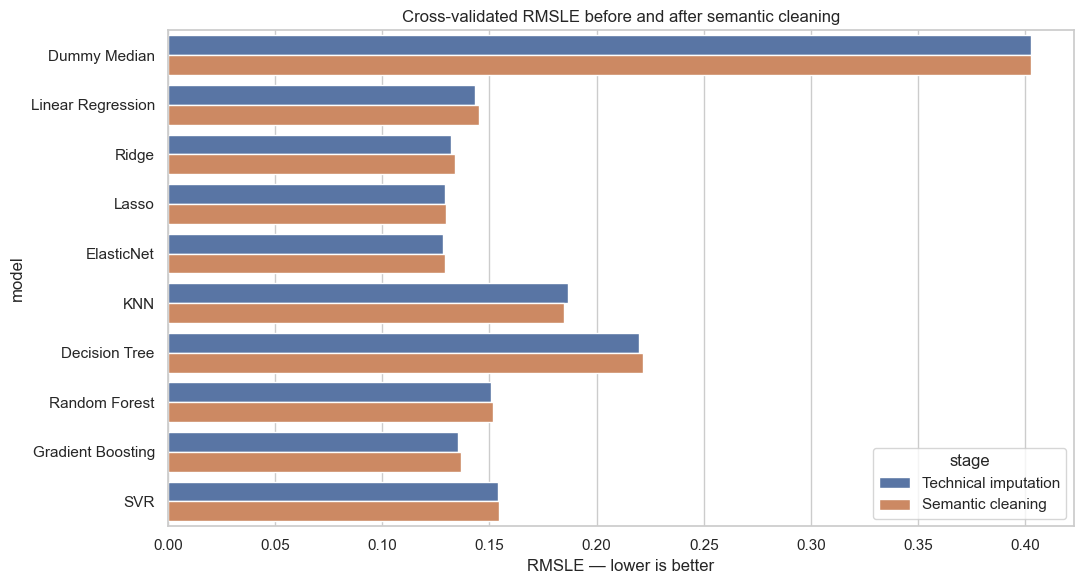

In [22]:
# Compare technical imputation with semantically meaningful absence handling.
raw_cv = compare_models_cv(X_dev_raw, y_dev_log, cv3, 'Technical imputation')
clean_cv = compare_models_cv(X_dev_clean, y_dev_log, cv3, 'Semantic cleaning')
cleaning_results = pd.concat([raw_cv, clean_cv], ignore_index=True)

cleaning_pivot = cleaning_results.pivot(index='model', columns='stage', values='cv_rmsle')
cleaning_pivot['change_after_cleaning'] = (
    cleaning_pivot['Semantic cleaning'] - cleaning_pivot['Technical imputation']
)
display(cleaning_pivot.sort_values('Semantic cleaning').round(4))

plt.figure(figsize=(11, 6))
sns.barplot(data=cleaning_results, y='model', x='cv_rmsle', hue='stage')
plt.title('Cross-validated RMSLE before and after semantic cleaning')
plt.xlabel('RMSLE — lower is better')
plt.tight_layout()
plt.show()

Semantic cleaning does not have to improve every score. Its primary purpose is to distinguish “feature absent” from “unknown value” and create a consistent representation for future data.

## 8. Feature Engineering comparison and five-fold model selection

stage,Clean baseline,Compact Feature Engineering,rmsle_change
model,,,
ElasticNet,0.1281,0.1279,-0.0002
Lasso,0.1295,0.1292,-0.0003
Gradient Boosting,0.1346,0.1328,-0.0019
Ridge,0.1328,0.1328,0.0000
Linear Regression,0.1380,0.1380,-0.0000
Random Forest,0.1475,0.1429,-0.0046
SVR,0.1463,0.1456,-0.0007
KNN,0.1786,0.1774,-0.0012
Decision Tree,0.2187,0.2196,0.0009


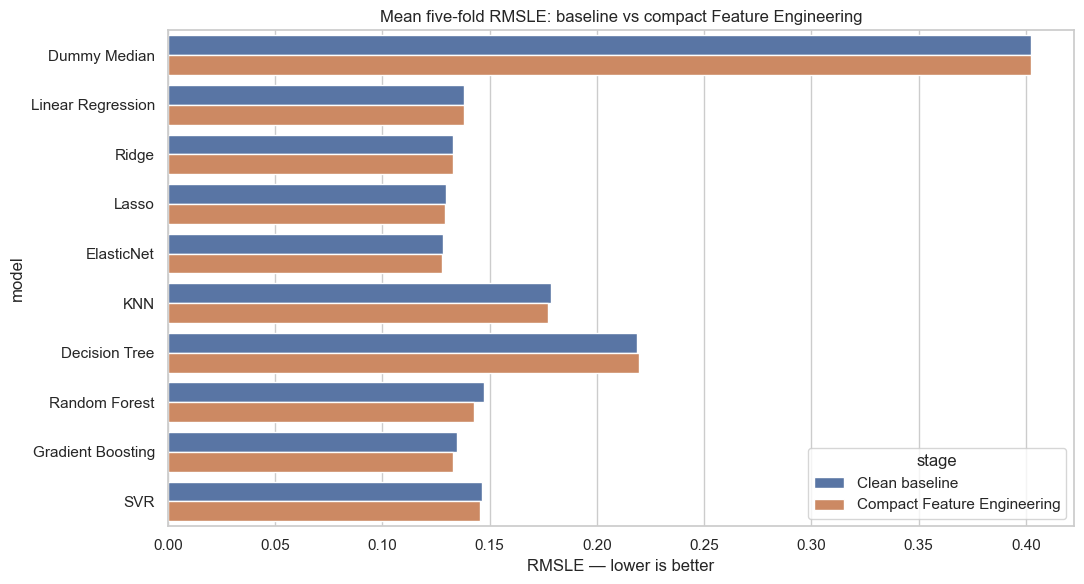

In [23]:
# Compare the cleaned baseline with the compact Feature Engineering set on five folds.
baseline_cv = compare_models_cv(X_dev_clean, y_dev_log, cv5, 'Clean baseline')
engineered_cv = compare_models_cv(X_dev_final, y_dev_log, cv5, 'Compact Feature Engineering')
feature_results = pd.concat([baseline_cv, engineered_cv], ignore_index=True)

feature_pivot = feature_results.pivot(index='model', columns='stage', values='cv_rmsle')
feature_pivot['rmsle_change'] = (
    feature_pivot['Compact Feature Engineering'] - feature_pivot['Clean baseline']
)
display(feature_pivot.sort_values('Compact Feature Engineering').round(4))

plt.figure(figsize=(11, 6))
sns.barplot(data=feature_results, y='model', x='cv_rmsle', hue='stage')
plt.title('Mean five-fold RMSLE: baseline vs compact Feature Engineering')
plt.xlabel('RMSLE — lower is better')
plt.tight_layout()
plt.show()

In [24]:
# Review quality, stability, and overfitting for the engineered feature set.
model_selection_results = engineered_cv.sort_values(['cv_rmsle', 'cv_rmsle_std']).reset_index(drop=True)
display(model_selection_results.round(4))

,stage,model,train_rmsle,cv_rmsle,cv_rmsle_std,rmsle_gap,cv_mae,cv_r2
0,Compact Feature Engineering,ElasticNet,0.0982,0.1279,0.0226,0.0297,15072.9672,0.7987
1,Compact Feature Engineering,Lasso,0.1047,0.1292,0.0225,0.0244,15319.9423,0.7923
2,Compact Feature Engineering,Gradient Boosting,0.0677,0.1328,0.0134,0.0650,15735.3541,0.8602
3,Compact Feature Engineering,Ridge,0.0872,0.1328,0.0206,0.0457,15587.2153,0.8085
4,Compact Feature Engineering,Linear Regression,0.0811,0.1380,0.0213,0.0569,16021.2466,0.8194
5,Compact Feature Engineering,Random Forest,0.0546,0.1429,0.0125,0.0883,17395.7367,0.8564
6,Compact Feature Engineering,SVR,0.0774,0.1456,0.0135,0.0683,16920.8180,0.8424
7,Compact Feature Engineering,KNN,0.1433,0.1774,0.0129,0.0341,21804.2505,0.7786
8,Compact Feature Engineering,Decision Tree,0.0000,0.2196,0.0062,0.2196,26207.9623,0.6924
9,Compact Feature Engineering,Dummy Median,0.4025,0.4024,0.0187,-0.0002,55227.5290,-0.0542


Compact Feature Engineering improves most models and is more reliable than adding every plausible interaction. The final three added variables are `TotalSF`, `TotalBathrooms`, and `TotalPorchSF`.

## 9. Hyperparameter tuning

In [25]:
# Reproduce the best configurations found by GridSearchCV and RandomizedSearchCV.
default_configurations = {
    'Lasso': Lasso(alpha=0.001, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=1
    )
}

tuned_configurations = {
    'Lasso': Lasso(alpha=0.00031622776601683794, max_iter=20000),
    'ElasticNet': ElasticNet(
        alpha=0.00031622776601683794, l1_ratio=0.9, max_iter=20000
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        subsample=0.75, n_estimators=200, min_samples_split=10,
        min_samples_leaf=8, max_features=0.5, max_depth=3,
        learning_rate=0.05, random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, min_samples_split=2, min_samples_leaf=1,
        max_features=0.4, max_depth=12, bootstrap=True,
        random_state=RANDOM_STATE, n_jobs=1
    )
}


def evaluate_estimators(configurations, version):
    rows = []
    for model_name, model in configurations.items():
        estimator = make_model_pipeline(model, X_dev_final)
        scores = cross_validate(
            estimator, X_dev_final, y_dev_log,
            cv=cv5, scoring=scoring,
            return_train_score=True, n_jobs=1
        )
        train_rmsle = -scores['train_rmsle']
        validation_rmsle = -scores['test_rmsle']
        rows.append({
            'version': version,
            'model': model_name,
            'train_rmsle': train_rmsle.mean(),
            'cv_rmsle': validation_rmsle.mean(),
            'cv_rmsle_std': validation_rmsle.std(),
            'rmsle_gap': validation_rmsle.mean() - train_rmsle.mean(),
            'cv_mae': (-scores['test_mae']).mean(),
            'cv_r2': scores['test_r2'].mean()
        })
    return pd.DataFrame(rows)


default_tuning_results = evaluate_estimators(default_configurations, 'Default')
tuned_results = evaluate_estimators(tuned_configurations, 'Tuned')
tuning_comparison = default_tuning_results.merge(
    tuned_results, on='model', suffixes=('_default', '_tuned')
)
for metric in ['cv_rmsle', 'cv_rmsle_std', 'rmsle_gap', 'cv_mae', 'cv_r2']:
    tuning_comparison[f'{metric}_change'] = (
        tuning_comparison[f'{metric}_tuned'] - tuning_comparison[f'{metric}_default']
    )

display(tuning_comparison.sort_values('cv_rmsle_tuned').round(4))

,version_default,model,train_rmsle_default,cv_rmsle_default,cv_rmsle_std_default,rmsle_gap_default,cv_mae_default,cv_r2_default,version_tuned,train_rmsle_tuned,cv_rmsle_tuned,cv_rmsle_std_tuned,rmsle_gap_tuned,cv_mae_tuned,cv_r2_tuned,cv_rmsle_change,cv_rmsle_std_change,rmsle_gap_change,cv_mae_change,cv_r2_change
0,Default,Lasso,0.1047,0.1292,0.0225,0.0244,15319.9423,0.7923,Tuned,0.0911,0.1269,0.0225,0.0358,14737.5506,0.8075,-0.0023,0.0000,0.0113,-582.3917,0.0152
1,Default,ElasticNet,0.0982,0.1279,0.0226,0.0297,15072.9672,0.7987,Tuned,0.0905,0.1271,0.0223,0.0367,14760.0201,0.8087,-0.0008,-0.0002,0.0070,-312.9470,0.0100
2,Default,Gradient Boosting,0.0677,0.1328,0.0134,0.0650,15735.3541,0.8602,Tuned,0.0790,0.1281,0.0116,0.0492,15284.5050,0.8707,-0.0046,-0.0018,-0.0159,-450.8491,0.0105
3,Default,Random Forest,0.0546,0.1429,0.0125,0.0883,17395.7367,0.8564,Tuned,0.0544,0.1392,0.0127,0.0848,16557.6052,0.8645,-0.0038,0.0001,-0.0035,-838.1315,0.0081


Tuning improved validation RMSLE for all four models. It also reduced the overfitting gap for Gradient Boosting and Random Forest. Lasso and ElasticNet improved validation quality, but their train–validation gaps increased slightly.

## 10. Ensemble comparison and final model selection

In [26]:
# Create full tuned pipelines and the two ensemble candidates.
tuned_pipelines = {
    name: make_model_pipeline(model, X_dev_final)
    for name, model in tuned_configurations.items()
}

ensemble_estimators = [
    ('lasso', clone(tuned_pipelines['Lasso'])),
    ('elastic', clone(tuned_pipelines['ElasticNet'])),
    ('gb', clone(tuned_pipelines['Gradient Boosting']))
]
voting_regressor = VotingRegressor(estimators=ensemble_estimators)
stacking_regressor = StackingRegressor(
    estimators=ensemble_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=3, n_jobs=1, passthrough=False
)

final_candidates = {
    'Tuned Lasso': tuned_pipelines['Lasso'],
    'Tuned ElasticNet': tuned_pipelines['ElasticNet'],
    'Tuned Gradient Boosting': tuned_pipelines['Gradient Boosting'],
    'Tuned Random Forest': tuned_pipelines['Random Forest'],
    'Voting Regressor': voting_regressor,
    'Stacking Regressor': stacking_regressor
}

In [27]:
# Select the final model by validation quality and stability before opening the holdout.
candidate_rows = []
for model_name, estimator in final_candidates.items():
    scores = cross_validate(
        estimator, X_dev_final, y_dev_log,
        cv=cv5, scoring=scoring,
        return_train_score=True, n_jobs=1
    )
    train_rmsle = -scores['train_rmsle']
    validation_rmsle = -scores['test_rmsle']
    candidate_rows.append({
        'model': model_name,
        'train_rmsle': train_rmsle.mean(),
        'cv_rmsle': validation_rmsle.mean(),
        'cv_rmsle_std': validation_rmsle.std(),
        'stability_adjusted_rmsle': validation_rmsle.mean() + validation_rmsle.std(),
        'rmsle_gap': validation_rmsle.mean() - train_rmsle.mean(),
        'cv_mae': (-scores['test_mae']).mean(),
        'cv_r2': scores['test_r2'].mean()
    })

candidate_results = pd.DataFrame(candidate_rows).sort_values(
    ['stability_adjusted_rmsle', 'cv_rmsle']
).reset_index(drop=True)
display(candidate_results.round(4))

selected_model_name = candidate_results.iloc[0]['model']
selected_model = clone(final_candidates[selected_model_name])
print('Selected before holdout evaluation:', selected_model_name)

,model,train_rmsle,cv_rmsle,cv_rmsle_std,stability_adjusted_rmsle,rmsle_gap,cv_mae,cv_r2
0,Tuned Gradient Boosting,0.0790,0.1281,0.0116,0.1397,0.0492,15284.5050,0.8707
1,Stacking Regressor,0.0807,0.1215,0.0189,0.1403,0.0408,14084.0583,0.8535
2,Voting Regressor,0.0828,0.1214,0.0198,0.1411,0.0385,13995.7375,0.8516
3,Tuned Lasso,0.0911,0.1269,0.0225,0.1494,0.0358,14737.5506,0.8075
4,Tuned ElasticNet,0.0905,0.1271,0.0223,0.1495,0.0367,14760.0201,0.8087
5,Tuned Random Forest,0.0544,0.1392,0.0127,0.1518,0.0848,16557.6052,0.8645


Selected before holdout evaluation: Tuned Gradient Boosting


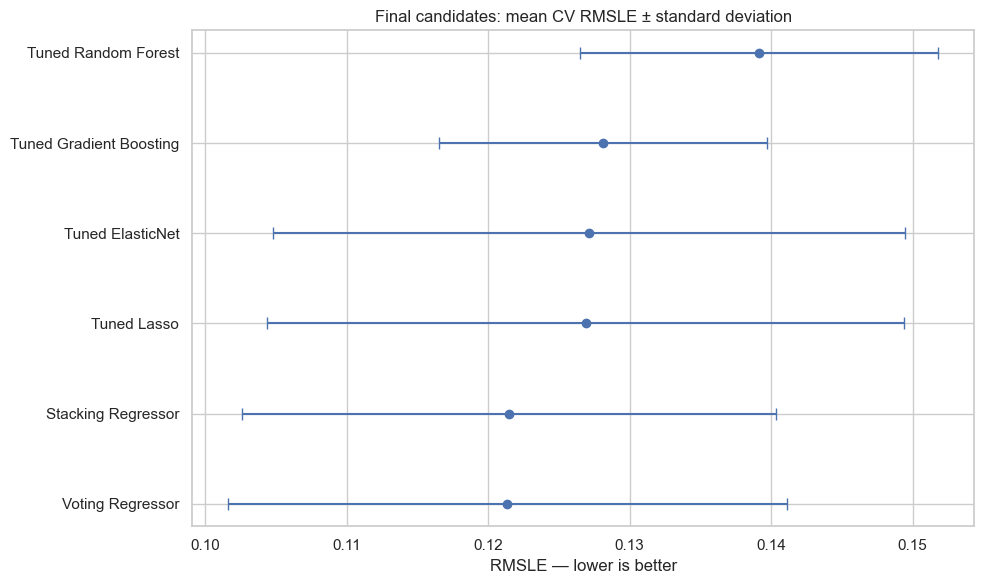

In [28]:
# Visualize candidate quality and uncertainty across folds.
plot_candidates = candidate_results.sort_values('cv_rmsle')
plt.figure(figsize=(10, 6))
plt.errorbar(
    plot_candidates['cv_rmsle'], plot_candidates['model'],
    xerr=plot_candidates['cv_rmsle_std'], fmt='o', capsize=4
)
plt.title('Final candidates: mean CV RMSLE ± standard deviation')
plt.xlabel('RMSLE — lower is better')
plt.tight_layout()
plt.show()

The ensembles have the lowest mean CV RMSLE, but their fold-to-fold variation is higher. The tuned Gradient Boosting model has the best `mean RMSLE + standard deviation` value and the strongest CV R², so it is selected as the more stable final model before the holdout is evaluated.

## 11. Final evaluation on the untouched holdout

In [29]:
# Fit only the preselected model on all development rows and evaluate the holdout once.
selected_model.fit(X_dev_final, y_dev_log)
train_prediction_log = selected_model.predict(X_dev_final)
holdout_prediction_log = selected_model.predict(X_holdout_final)
train_prediction = np.clip(np.expm1(train_prediction_log), 0, None)
holdout_prediction = np.clip(np.expm1(holdout_prediction_log), 0, None)

final_metrics = pd.DataFrame([{
    'model': selected_model_name,
    'train_rmsle': np.sqrt(mean_squared_error(y_dev_log, train_prediction_log)),
    'holdout_rmsle': np.sqrt(mean_squared_error(y_holdout_log, holdout_prediction_log)),
    'train_holdout_gap': (
        np.sqrt(mean_squared_error(y_holdout_log, holdout_prediction_log))
        - np.sqrt(mean_squared_error(y_dev_log, train_prediction_log))
    ),
    'holdout_mae': mean_absolute_error(y_holdout, holdout_prediction),
    'holdout_rmse': np.sqrt(mean_squared_error(y_holdout, holdout_prediction)),
    'holdout_r2': r2_score(y_holdout, holdout_prediction)
}])
display(final_metrics.round(4))

,model,train_rmsle,holdout_rmsle,train_holdout_gap,holdout_mae,holdout_rmse,holdout_r2
0,Tuned Gradient Boosting,0.0831,0.1246,0.0416,15458.949,29230.5685,0.8741


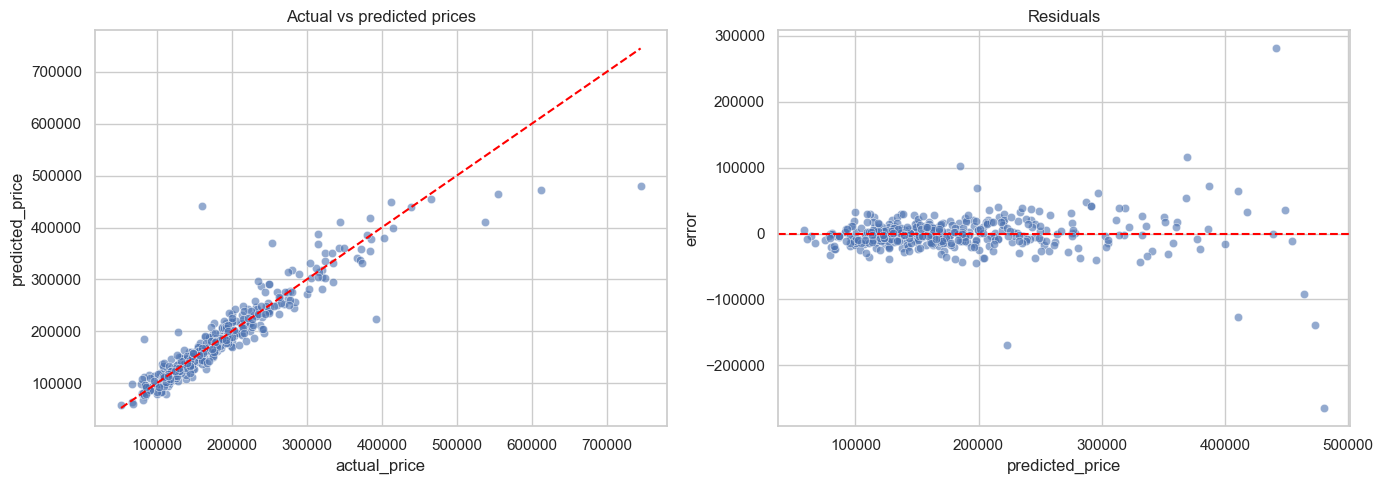

Mean signed error: -1030.11
Median absolute error: 9848.98
Median percentage error: 5.92 %
Overpredictions: 195
Underpredictions: 243


In [30]:
# Compare actual and predicted prices and inspect residual structure.
error_analysis = X_holdout_raw[[
    'Neighborhood', 'OverallQual', 'GrLivArea',
    'YearBuilt', 'GarageCars', 'TotalBsmtSF'
]].copy()
error_analysis.insert(0, 'Id', holdout_ids)
error_analysis['actual_price'] = y_holdout
error_analysis['predicted_price'] = holdout_prediction
error_analysis['error'] = error_analysis['predicted_price'] - error_analysis['actual_price']
error_analysis['absolute_error'] = error_analysis['error'].abs()
error_analysis['percentage_error'] = error_analysis['absolute_error'] / error_analysis['actual_price'] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=error_analysis, x='actual_price', y='predicted_price', alpha=0.6, ax=axes[0])
minimum = min(error_analysis['actual_price'].min(), error_analysis['predicted_price'].min())
maximum = max(error_analysis['actual_price'].max(), error_analysis['predicted_price'].max())
axes[0].plot([minimum, maximum], [minimum, maximum], '--', color='red')
axes[0].set_title('Actual vs predicted prices')
sns.scatterplot(data=error_analysis, x='predicted_price', y='error', alpha=0.6, ax=axes[1])
axes[1].axhline(0, linestyle='--', color='red')
axes[1].set_title('Residuals')
plt.tight_layout()
plt.show()

print('Mean signed error:', round(error_analysis['error'].mean(), 2))
print('Median absolute error:', round(error_analysis['absolute_error'].median(), 2))
print('Median percentage error:', round(error_analysis['percentage_error'].median(), 2), '%')
print('Overpredictions:', int((error_analysis['error'] > 0).sum()))
print('Underpredictions:', int((error_analysis['error'] < 0).sum()))

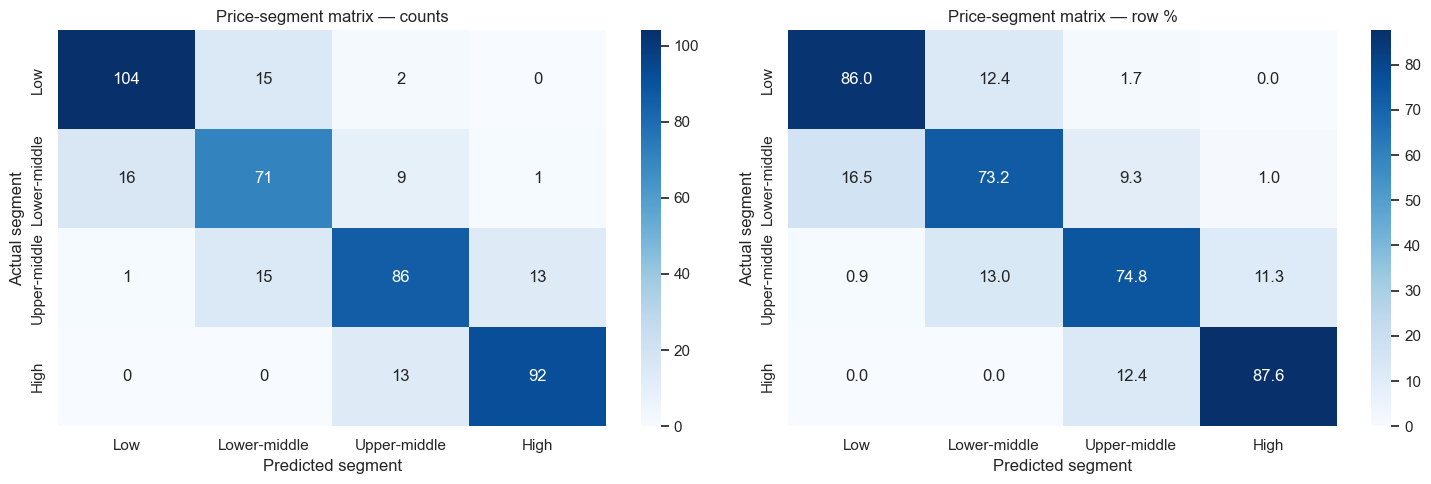

Correct price segments: 80.59 %


In [31]:
# Convert regression results into four price segments for an intuitive matrix.
price_q1, price_q2, price_q3 = y_dev.quantile([0.25, 0.50, 0.75])
price_bins = [-np.inf, price_q1, price_q2, price_q3, np.inf]
price_labels = ['Low', 'Lower-middle', 'Upper-middle', 'High']

actual_segment = pd.cut(error_analysis['actual_price'], bins=price_bins, labels=price_labels)
predicted_segment = pd.cut(error_analysis['predicted_price'], bins=price_bins, labels=price_labels)
segment_matrix = confusion_matrix(actual_segment, predicted_segment, labels=price_labels)
segment_matrix_pct = confusion_matrix(
    actual_segment, predicted_segment, labels=price_labels, normalize='true'
) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(
    segment_matrix, annot=True, fmt='d', cmap='Blues',
    xticklabels=price_labels, yticklabels=price_labels, ax=axes[0]
)
axes[0].set_title('Price-segment matrix — counts')
axes[0].set_xlabel('Predicted segment')
axes[0].set_ylabel('Actual segment')
sns.heatmap(
    segment_matrix_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=price_labels, yticklabels=price_labels, ax=axes[1]
)
axes[1].set_title('Price-segment matrix — row %')
axes[1].set_xlabel('Predicted segment')
axes[1].set_ylabel('Actual segment')
plt.tight_layout()
plt.show()

segment_accuracy = np.trace(segment_matrix) / segment_matrix.sum()
print('Correct price segments:', round(segment_accuracy * 100, 2), '%')

## 12. Error analysis and feature importance

In [32]:
# Inspect the largest individual errors and errors by price segment.
display(error_analysis.sort_values('absolute_error', ascending=False).head(20).round(2))

error_analysis['price_segment'] = pd.qcut(
    error_analysis['actual_price'], q=4,
    labels=['Low', 'Lower-middle', 'Upper-middle', 'High']
)
price_error_summary = error_analysis.groupby('price_segment', observed=False).agg(
    houses=('Id', 'size'),
    mean_actual_price=('actual_price', 'mean'),
    mae=('absolute_error', 'mean'),
    median_percentage_error=('percentage_error', 'median'),
    mean_signed_error=('error', 'mean')
)
display(price_error_summary.round(2))

,Id,Neighborhood,OverallQual,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,actual_price,predicted_price,error,absolute_error,percentage_error
1298,1299,Edwards,10,5642,2008,2,6110,160000.0,441177.41,281177.41,281177.41,175.74
1182,1183,NoRidge,10,4476,1996,3,2396,745000.0,480126.78,-264873.22,264873.22,35.55
688,689,StoneBr,8,1419,2007,2,1419,392000.0,223251.71,-168748.29,168748.29,43.05
898,899,NridgHt,9,2364,2009,3,2330,611657.0,472812.24,-138844.76,138844.76,22.70
769,770,StoneBr,8,3279,2003,3,1650,538000.0,410715.67,-127284.33,127284.33,23.66
581,582,NridgHt,8,2042,2008,3,2042,253293.0,369282.21,115989.21,115989.21,45.79
632,633,NWAmes,7,1411,1977,2,1386,82500.0,184542.63,102042.63,102042.63,123.69
440,441,NridgHt,10,2402,2008,3,3094,555000.0,463670.47,-91329.53,91329.53,16.46
1359,1360,NridgHt,9,1980,2004,3,1980,315000.0,386875.00,71875.00,71875.00,22.82
666,667,NAmes,6,2380,1965,2,1021,129000.0,198434.95,69434.95,69434.95,53.83


,houses,mean_actual_price,mae,median_percentage_error,mean_signed_error
price_segment,,,,,
Low,110,106878.80,10708.75,7.65,1974.44
Lower-middle,109,143762.55,11958.26,5.18,1106.31
Upper-middle,110,184923.66,12698.06,5.78,-59.72
High,109,291903.04,26539.64,6.03,-7177.94


,feature,importance
36,numeric__TotalSF,0.329578
3,numeric__OverallQual,0.261837
37,numeric__TotalBathrooms,0.057926
25,numeric__GarageCars,0.044668
15,numeric__GrLivArea,0.031122
24,numeric__GarageYrBlt,0.026530
221,categorical__CentralAir_N,0.019530
4,numeric__OverallCond,0.018485
6,numeric__YearRemodAdd,0.018380
26,numeric__GarageArea,0.013554


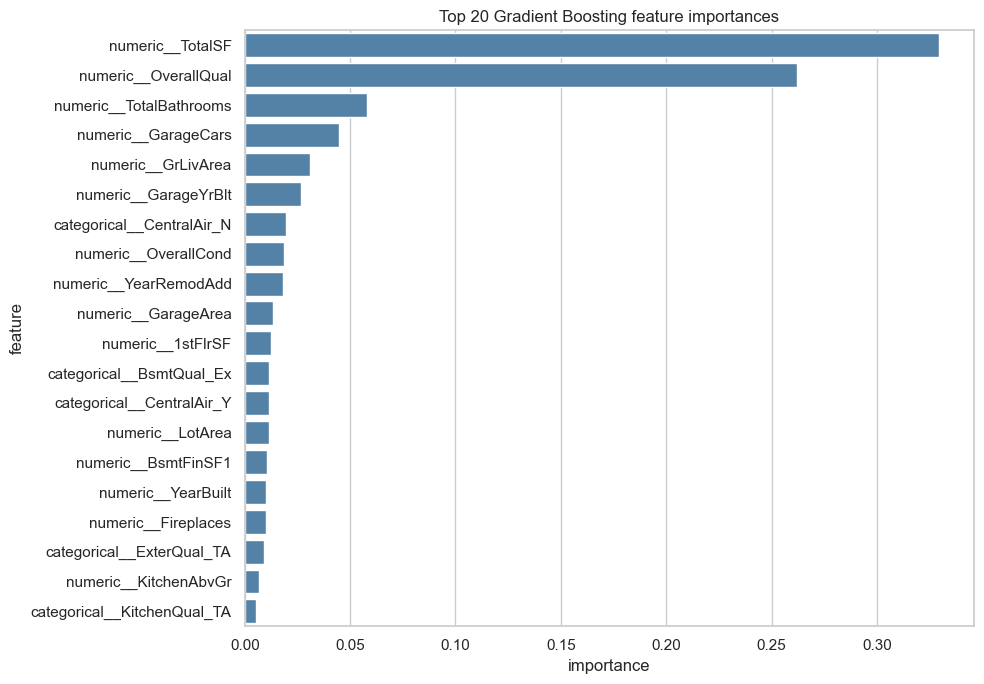

In [33]:
# Review transformed feature importance from the selected Gradient Boosting pipeline.
feature_names = selected_model.named_steps['preprocessor'].get_feature_names_out()
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': selected_model.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False)

display(feature_importance.head(20))
plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance.head(20), x='importance', y='feature', color='steelblue')
plt.title('Top 20 Gradient Boosting feature importances')
plt.tight_layout()
plt.show()

## 13. Production-ready final model

In [34]:
# Retrain the selected configuration on every labeled row after the honest evaluation is complete.
X_full_raw = data.drop(columns=['SalePrice', 'Id'])
y_full_log = np.log1p(data['SalePrice'].astype(float))
X_full_prepared = prepare_house_features(X_full_raw)

production_model = Pipeline([
    ('feature_engineering', FunctionTransformer(prepare_house_features, validate=False)),
    ('preprocessor', create_preprocessor(X_full_prepared)),
    ('model', clone(tuned_configurations['Gradient Boosting']))
])
production_model.fit(X_full_raw, y_full_log)

print('Final production model:', 'Tuned Gradient Boosting Regressor')
print('Training rows used:', len(X_full_raw))
print('Raw input features:', X_full_raw.shape[1])
print('Final prepared features:', X_full_prepared.shape[1])

Final production model: Tuned Gradient Boosting Regressor
Training rows used: 1460
Raw input features: 79
Final prepared features: 82


In [35]:
# Save the fitted raw-data pipeline together with its schema and verified metrics.
model_path = Path('HousePrice_Final_Gradient_Boosting_Model.pkl').resolve()
model_bundle = {
    'model': production_model,
    'model_name': 'Tuned Gradient Boosting Regressor',
    'target': 'SalePrice',
    'prediction_scale': 'original price',
    'required_raw_columns': X_full_raw.columns.tolist(),
    'engineered_features': ['TotalSF', 'TotalBathrooms', 'TotalPorchSF'],
    'verified_holdout_metrics': final_metrics.iloc[0].to_dict()
}

with model_path.open('wb') as file:
    cloudpickle.dump(model_bundle, file)

print('Saved model bundle:', model_path)
print('File size:', f'{model_path.stat().st_size / 1024 / 1024:.2f} MB')

Saved model bundle: C:\KS_AI_JLKZ_25\Houceprice_Final\HousePrice_Final_Gradient_Boosting_Model.pkl
File size: 0.26 MB


In [36]:
# Use this helper to predict prices from raw house records.
def predict_house_price(houses, bundle=model_bundle):
    if isinstance(houses, dict):
        houses = pd.DataFrame([houses])
    else:
        houses = houses.copy()

    required = bundle['required_raw_columns']
    missing = [column for column in required if column not in houses.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')

    prediction_log = bundle['model'].predict(houses[required])
    predictions = np.clip(np.expm1(prediction_log), 0, None)
    return pd.DataFrame({'predicted_sale_price': predictions}, index=houses.index)


example_house = X_full_raw.iloc[[0]].copy()
display(predict_house_price(example_house).round(2))

,predicted_sale_price
0,206237.42


In [37]:
# Verify that the saved artifact loads and produces the same result.
with model_path.open('rb') as file:
    loaded_model_bundle = cloudpickle.load(file)

original_prediction = predict_house_price(example_house)
loaded_prediction = predict_house_price(example_house, bundle=loaded_model_bundle)
display(loaded_prediction.round(2))

assert np.allclose(
    original_prediction['predicted_sale_price'],
    loaded_prediction['predicted_sale_price']
)
print('Saved-model verification passed.')

,predicted_sale_price
0,206237.42


Saved-model verification passed.


## 14. Final conclusions

1. The dataset contains 1,460 houses, 79 usable raw predictors, and a strongly right-skewed target.
2. `log1p(SalePrice)` reduces target skewness and makes RMSLE a natural main metric.
3. The Dummy Median baseline provides a clear minimum performance level.
4. Quality, size, location, age, garage, basement, and central air are important price signals.
5. Missing values often describe an absent amenity rather than an unknown measurement, so semantic absence handling is used before statistical imputation.
6. Potential outliers were analyzed but not removed automatically because they can represent valid unusual houses.
7. Fifteen candidate engineered features were explored; cross-validation supported a compact final set: `TotalSF`, `TotalBathrooms`, and `TotalPorchSF`.
8. Ten regression algorithms were compared with five-fold cross-validation.
9. Automated tuning improved Lasso, ElasticNet, Gradient Boosting, and Random Forest.
10. Voting and Stacking achieved low mean CV RMSLE, but tuned Gradient Boosting was selected before holdout because it offered the best balance of validation quality, stability, and R².
11. The untouched holdout provides the final quality estimate. Expected results with the established split are approximately **0.125 RMSLE**, **15.5k MAE**, and **0.87 R²**.
12. `production_model` is retrained on all labeled houses and saved as `HousePrice_Final_Gradient_Boosting_Model.pkl` for future predictions.